In [1]:
#imports
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## (I) data prepration:
## dataframes:
managers_df = pd.read_csv(r"C:\Users\lidor\OneDrive\Desktop\חומר למבחן\managers.csv")
positions_df = pd.read_csv(r"C:\Users\lidor\OneDrive\Desktop\חומר למבחן\positions.csv")
jobs_df = pd.read_csv(r"C:\Users\lidor\OneDrive\Desktop\חומר למבחן\jobs.csv")
employees_df = pd.read_csv(r"C:\Users\lidor\OneDrive\Desktop\חומר למבחן\employees.csv")

In [3]:
## copies:
employees_df_copy = employees_df.copy()
jobs_df_copy = jobs_df.copy()
positions_df_copy = positions_df.copy()
managers_df_copy = managers_df.copy()


In [4]:
#1 A
## Handle duplicate data in job dataset: 
## i want to find first all duplicates job title:
duplicate_jobs = jobs_df_copy[jobs_df_copy.duplicated(subset=['job_title'], keep=False)]
duplicate_jobs 

,job_id,job_title,department
0,1,Front-End Developer,R&D
1,2,Back-End Developer,R&D
2,3,Full-Stack Developer,R&D
3,4,DevOps Engineer,R&D
4,5,UX Designer,Design
5,6,UI Designer,Design
6,7,Graphic Designer,Design
29,30,Front-End Developer,R&D
30,31,Back-End Developer,R&D
31,32,Full-Stack Developer,R&D


In [5]:
# 1 B mapping in dictinorry the duplicates job titles:
jobs_map = {30: 1, 31: 2, 32: 3, 33: 4, 34: 5, 35: 6, 36: 7}
# repalcing job ID in the positions df:
positions_df_copy['job_id'] = positions_df_copy['job_id'].replace(jobs_map)
# because there is no nulls in the df i will keep the first:
jobs_df_copy.drop_duplicates(subset=['job_title'], keep='first', inplace=True)
jobs_df_copy

,job_id,job_title,department
0,1,Front-End Developer,R&D
1,2,Back-End Developer,R&D
2,3,Full-Stack Developer,R&D
3,4,DevOps Engineer,R&D
4,5,UX Designer,Design
5,6,UI Designer,Design
6,7,Graphic Designer,Design
7,8,Web Designer,Design
8,9,Product Designer,Design
9,10,Product Manager,Product Management


In [6]:
## 2. Handle missing data in all datasets: 
# a. checking null precntage in any coulmns in the datasets:
print("Employees Missing Percentage:\n", (employees_df_copy.isnull().sum() / len(employees_df_copy)) * 100)
print("\nManagers Missing Percentage:\n", (managers_df_copy.isnull().sum() / len(managers_df_copy)) * 100)
print("\nJobs Missing Percentage:\n", (jobs_df_copy.isnull().sum() / len(jobs_df_copy)) * 100)
print("\nPositions Missing Percentage:\n", (positions_df_copy.isnull().sum() / len(positions_df_copy)) * 100)

Employees Missing Percentage:
 employee_id            0.0
manager_id             6.2
first_name             0.0
last_name              0.0
email                  0.0
age                    8.4
gender                 7.4
nationality            0.0
years_of_experience    5.6
salary                 3.4
dtype: float64

Managers Missing Percentage:
 manager_id              0.0
first_name              0.0
last_name               0.0
email                   0.0
age                     6.0
gender                 13.0
nationality             0.0
starting_date          10.0
years_of_experience     5.0
salary                  0.0
performance_score       0.0
dtype: float64

Jobs Missing Percentage:
 job_id        0.0
job_title     0.0
department    0.0
dtype: float64

Positions Missing Percentage:
 position_id           0.0
employee_id           0.0
job_id                3.4
position_location     0.0
starting_date        10.9
performance_score    10.0
dtype: float64


In [7]:
## b. fill the missing data with a default valid value in empoleeys
# calculate the avareage years of expirence
mean_experience = round(employees_df_copy['years_of_experience'].mean())
#calculate the avareage years of expirence
employees_df_copy['years_of_experience'] = employees_df_copy['years_of_experience'].fillna(mean_experience)
# fill the missing value of gender with unknown
employees_df_copy['gender'] = employees_df_copy['gender'].fillna('Unknown')
#age fill with mean
mean_employees_age = round(employees_df_copy['age'].mean())
employees_df_copy['age'] = employees_df_copy['age'].fillna(mean_employees_age)
#salary fill with mean
employees_df_copy = employees_df_copy.dropna(subset=['salary'])
employees_df_copy['manager_id'] = employees_df_copy['manager_id'].fillna(0)
print(employees_df_copy.isnull().sum())

employee_id            0
manager_id             0
first_name             0
last_name              0
email                  0
age                    0
gender                 0
nationality            0
years_of_experience    0
salary                 0
dtype: int64


In [8]:
## b. fill the missing data with a default valid value in managers
# calculate the avareage years of expirence
mean_mgr_experience = round(managers_df_copy['years_of_experience'].mean())
# calculate the avareage years of expirence
managers_df_copy['years_of_experience'] = managers_df_copy['years_of_experience'].fillna(mean_mgr_experience)
# fill the missing value of age with mean 
mean_mgr_age = round(managers_df_copy['age'].mean())
#age fill with mean
managers_df_copy['age'] = managers_df_copy['age'].fillna(mean_mgr_age)
# fill the missing value of gender with unknown
managers_df_copy['gender'] = managers_df_copy['gender'].fillna('Unknown')
#fill starting date with defualt
managers_df_copy['starting_date'] = managers_df_copy['starting_date'].fillna('2020-01-01')
print(managers_df_copy.isnull().sum())


manager_id             0
first_name             0
last_name              0
email                  0
age                    0
gender                 0
nationality            0
starting_date          0
years_of_experience    0
salary                 0
performance_score      0
dtype: int64


In [9]:
## b. fill the missing data with a default valid value in posirions:
# fill job_id with the defualt 0
positions_df_copy = positions_df_copy.dropna(subset=['job_id'])
# fill starting date with default date( the first one)
positions_df_copy['starting_date'] = positions_df_copy['starting_date'].fillna('2020-01-01')
# fill performance_score with mean
mean_perf = round(positions_df_copy['performance_score'].mean())
positions_df_copy['performance_score'] = positions_df_copy['performance_score'].fillna(mean_perf)
print(positions_df_copy.isnull().sum())

position_id          0
employee_id          0
job_id               0
position_location    0
starting_date        0
performance_score    0
dtype: int64


In [10]:
print("Employees Missing Percentage:\n", (employees_df_copy.isnull().sum() / len(employees_df_copy)) * 100)
print("\nManagers Missing Percentage:\n", (managers_df_copy.isnull().sum() / len(managers_df_copy)) * 100)
print("\nJobs Missing Percentage:\n", (jobs_df_copy.isnull().sum() / len(jobs_df_copy)) * 100)
print("\nPositions Missing Percentage:\n", (positions_df_copy.isnull().sum() / len(positions_df_copy)) * 100)

Employees Missing Percentage:
 employee_id            0.0
manager_id             0.0
first_name             0.0
last_name              0.0
email                  0.0
age                    0.0
gender                 0.0
nationality            0.0
years_of_experience    0.0
salary                 0.0
dtype: float64

Managers Missing Percentage:
 manager_id             0.0
first_name             0.0
last_name              0.0
email                  0.0
age                    0.0
gender                 0.0
nationality            0.0
starting_date          0.0
years_of_experience    0.0
salary                 0.0
performance_score      0.0
dtype: float64

Jobs Missing Percentage:
 job_id        0.0
job_title     0.0
department    0.0
dtype: float64

Positions Missing Percentage:
 position_id          0.0
employee_id          0.0
job_id               0.0
position_location    0.0
starting_date        0.0
performance_score    0.0
dtype: float64


In [11]:
#c. drop rows with missing mandator data employees: 
employees_df_copy = employees_df_copy.dropna(subset=['employee_id'])
employees_df_copy


,employee_id,manager_id,first_name,last_name,email,age,gender,nationality,years_of_experience,salary
0,1,0.0,Durant,Phripp,dphripp0@cbc.ca,60.0,Male,Italy,8.0,12184.0
1,2,80.0,Chastity,MacHostie,cmachostie1@nytimes.com,63.0,Female,Germany,13.0,21968.0
2,3,3.0,Rayna,Stemson,rstemson2@opensource.org,27.0,Unknown,Japan,12.0,28725.0
3,4,94.0,Forest,Dillway,fdillway3@myspace.com,45.0,Male,Japan,8.0,29375.0
4,5,25.0,Kristel,Mooreed,kmooreed4@thetimes.co.uk,24.0,Female,France,10.0,21709.0
...,...,...,...,...,...,...,...,...,...,...
495,496,11.0,Ezri,Ipwell,eipwelldr@github.com,57.0,Male,Israel,7.0,18306.0
496,497,90.0,Demetris,Hoggins,dhogginsds@ucoz.ru,41.0,Female,China,8.0,15884.0
497,498,83.0,Selena,Pedican,spedicandt@homestead.com,60.0,Female,Italy,5.0,13687.0
498,499,49.0,Freddie,Attenborrow,fattenborrowdu@wisc.edu,50.0,Unknown,Australia,9.0,16985.0


In [12]:
#c. drop rows with missing mandator data positions: 
positions_df_copy = positions_df_copy.dropna(subset=['position_id', 'employee_id'])
positions_df_copy

,position_id,employee_id,job_id,position_location,starting_date,performance_score
0,1,331,17.0,Germany,2020-04-05,8.0
1,2,345,9.0,United States,2022-07-11,8.0
2,3,51,20.0,Spain,2023-10-19,8.0
3,4,430,21.0,Singapore,2023-03-26,7.0
4,5,127,7.0,Israel,2020-09-15,8.0
...,...,...,...,...,...,...
994,995,493,22.0,United States,2020-01-01,7.0
996,997,117,15.0,Argentina,2020-06-29,5.0
997,998,25,1.0,France,2020-01-01,7.0
998,999,7,21.0,Argentina,2022-08-24,6.0


In [13]:
#c. drop rows with missing mandator data jobs: 
jobs_df_copy = jobs_df_copy.dropna(subset=['job_id', 'job_title'])
jobs_df_copy

,job_id,job_title,department
0,1,Front-End Developer,R&D
1,2,Back-End Developer,R&D
2,3,Full-Stack Developer,R&D
3,4,DevOps Engineer,R&D
4,5,UX Designer,Design
5,6,UI Designer,Design
6,7,Graphic Designer,Design
7,8,Web Designer,Design
8,9,Product Designer,Design
9,10,Product Manager,Product Management


In [14]:
#c. drop rows with missing mandator data managers: 
managers_df_copy = managers_df_copy.dropna(subset=['manager_id'])
managers_df_copy 

,manager_id,first_name,last_name,email,age,gender,nationality,starting_date,years_of_experience,salary,performance_score
0,1,Tootsie,Collip,tcollip0@dailymotion.com,39.0,Female,Australia,2023-10-08,14.0,44194,7
1,2,Delano,Arnet,darnet1@phpbb.com,47.0,Male,Israel,2023-06-06,22.0,21201,6
2,3,Jakie,Sygrove,jsygrove2@goo.gl,59.0,Male,Japan,2023-11-05,26.0,32562,9
3,4,Gustavo,Schohier,gschohier3@mtv.com,59.0,Male,China,2021-10-15,16.0,47577,9
4,5,Martin,Smitherman,msmitherman4@businessweek.com,46.0,Agender,Germany,2020-07-03,28.0,35462,6
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Ennis,Maidlow,emaidlow2n@yellowpages.com,38.0,Male,Spain,2022-09-02,22.0,52314,7
96,97,Dionne,Maudlin,dmaudlin2o@mlb.com,54.0,Female,Russia,2020-10-31,16.0,46955,8
97,98,Sawyer,Knightley,sknightley2p@constantcontact.com,47.0,Male,Japan,2023-10-29,11.0,22645,3
98,99,Burnard,Rubrow,brubrow2q@cafepress.com,33.0,Male,France,2023-03-30,12.0,23835,8


In [15]:
#2.a the number of employees by nationality
# use the methood strip to to find the word
employees_df_copy.columns = employees_df_copy.columns.str.strip()
nationality_counts = employees_df_copy['nationality'].value_counts()
nationality_df = nationality_counts.reset_index(name='employee_count')
print(nationality_df)

       nationality  employee_count
0    United States             104
1          Germany              72
2           Israel              55
3            Japan              28
4   United Kingdom              25
5            China              24
6           Brazil              23
7           Russia              23
8            Spain              22
9           France              20
10       Australia              20
11           Italy              19
12          Canada              19
13           India              15
14          Mexico              14


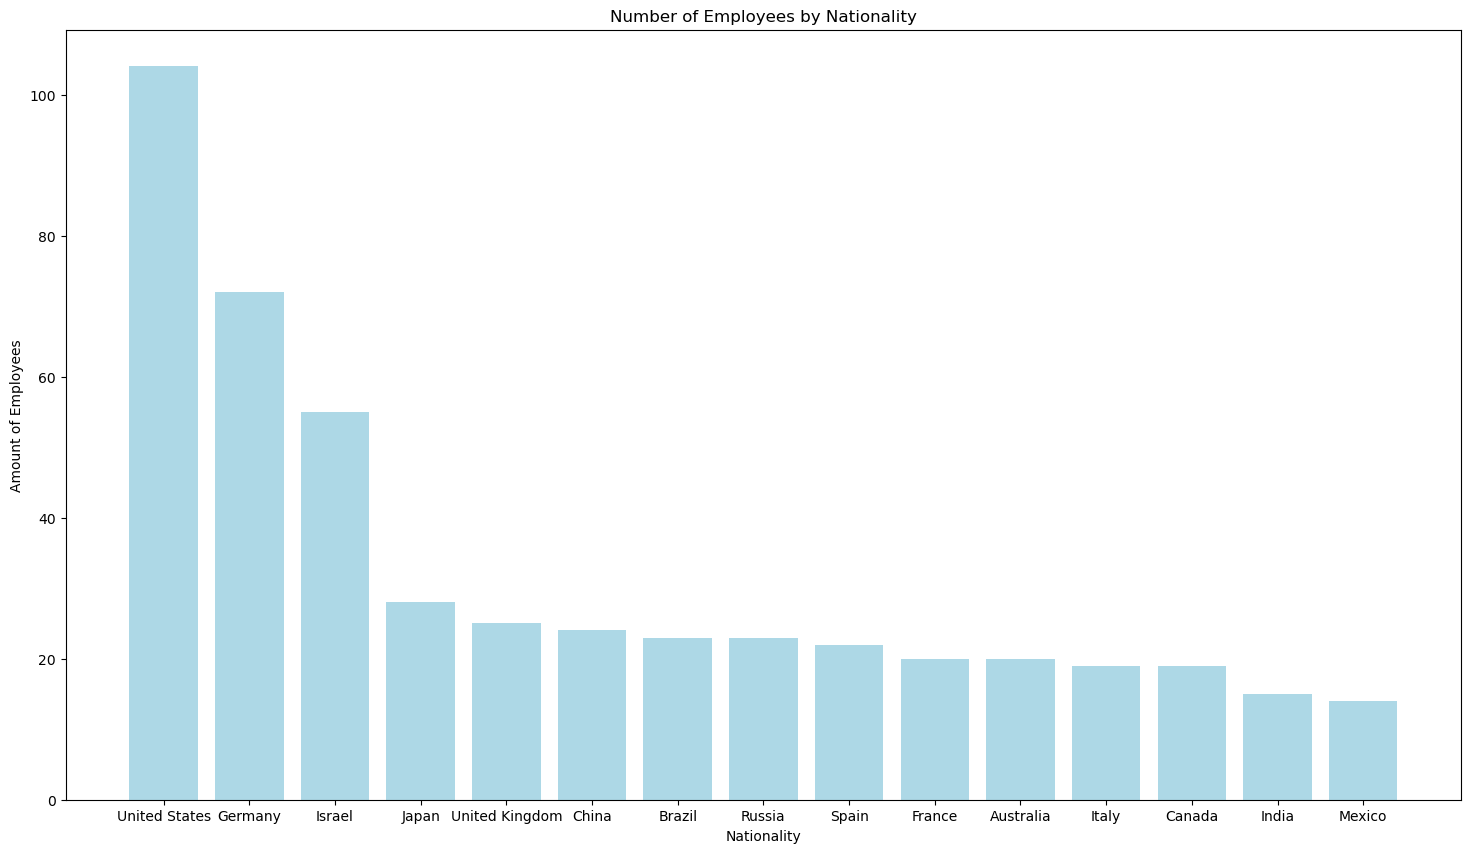

In [16]:
# a. i have used Plot bar chart to visualize the result
plt.figure(figsize=(18, 10))
plt.bar(nationality_df['nationality'], nationality_df['employee_count'], color='lightblue')
plt.title('Number of Employees by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Amount of Employees')
plt.show()

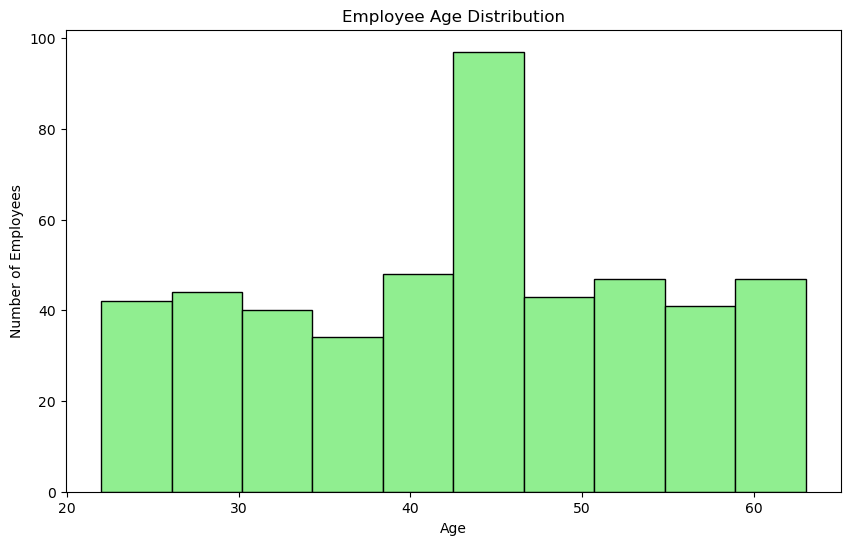

In [17]:
#b.employee age distribution with histogram chart
plt.figure(figsize=(10, 6))
plt.hist(employees_df_copy['age'], bins=10, edgecolor='black', color='lightgreen')
plt.title('Employee Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

In [18]:
#c. sort the employees table from lowest salary to the highest
sorted_salary_df = employees_df_copy.sort_values(by='salary', ascending=False)
columns_to_show = ['employee_id', 'first_name', 'last_name', 'age', 'years_of_experience', 'salary']

top_3_highest = sorted_salary_df[columns_to_show].head(3)

top_3_lowest = sorted_salary_df[columns_to_show].tail(3)
# i have used concat to join the two dataframe
extreme_salaries_df = pd.concat([top_3_highest, top_3_lowest])


extreme_salaries_df

,employee_id,first_name,last_name,age,years_of_experience,salary
204,205,Angel,Putton,33.0,11.0,34924.0
177,178,Stafani,Mc Dermid,50.0,8.0,34875.0
86,87,Arvin,Kuhnt,22.0,12.0,34719.0
450,451,Kamillah,Scrimgeour,43.0,7.0,9070.0
343,344,Donelle,Ingram,40.0,2.0,9051.0
312,313,Dorena,Leyband,37.0,12.0,9002.0


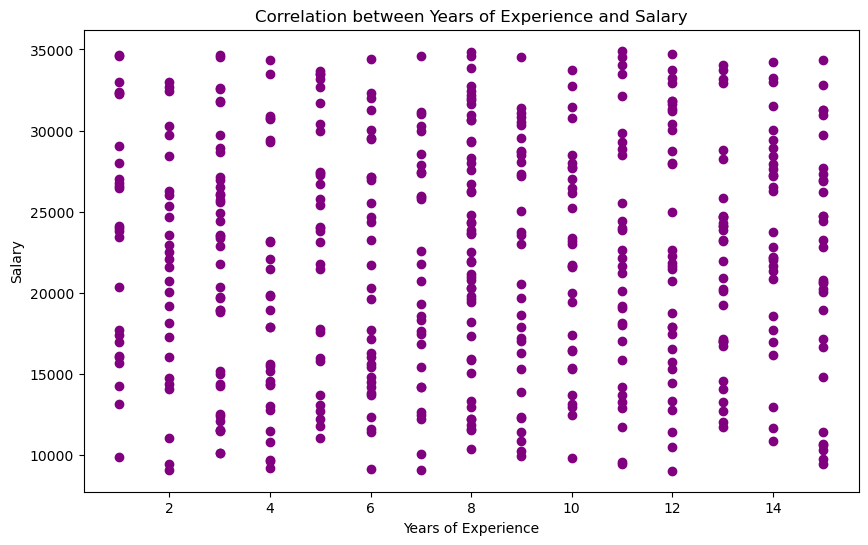

In [19]:
#d. scatter plot to check corallation:
plt.figure(figsize=(10, 6))
plt.scatter(employees_df_copy['years_of_experience'], employees_df_copy['salary'], color='purple')
plt.title('Correlation between Years of Experience and Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [20]:
# after exmine there is not coralltion between years of expirence and salary 

In [21]:
# strip all spaces from coulmns name:
managers_df_copy.columns = managers_df_copy.columns.str.strip()
jobs_df_copy.columns = jobs_df_copy.columns.str.strip()

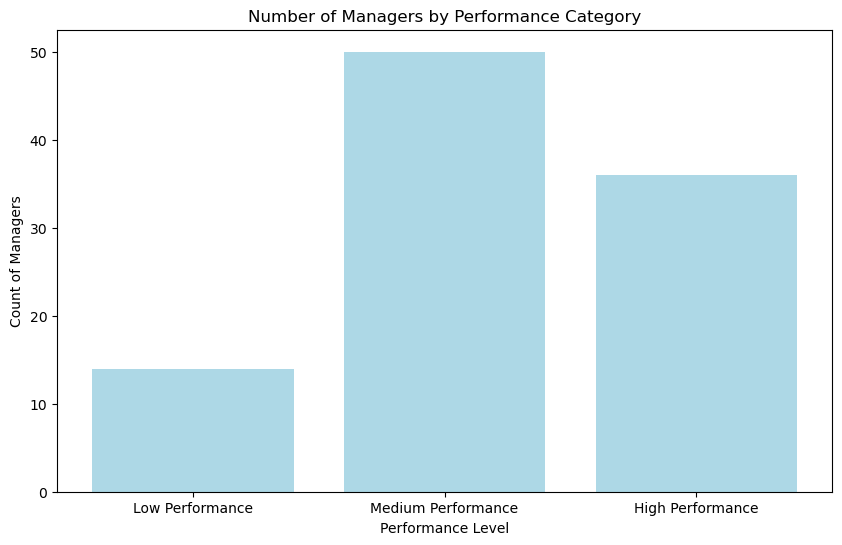

In [22]:
#2a . Count the number of managers by performance score 
low_perf = managers_df_copy[(managers_df_copy['performance_score'] >= 1) & (managers_df_copy['performance_score'] <= 5)]['manager_id'].count()
med_perf = managers_df_copy[(managers_df_copy['performance_score'] >= 6) & (managers_df_copy['performance_score'] <= 7)]['manager_id'].count()
high_perf = managers_df_copy[(managers_df_copy['performance_score'] >= 8) & (managers_df_copy['performance_score'] <= 10)]['manager_id'].count()
#visualization:
performance_labels = ['Low Performance', 'Medium Performance', 'High Performance']
performance_counts = [low_perf, med_perf, high_perf]
#plotbar
plt.figure(figsize=(10, 6))
plt.bar(performance_labels, performance_counts, color='lightblue')
plt.title('Number of Managers by Performance Category')
plt.xlabel('Performance Level')
plt.ylabel('Count of Managers')
plt.show()

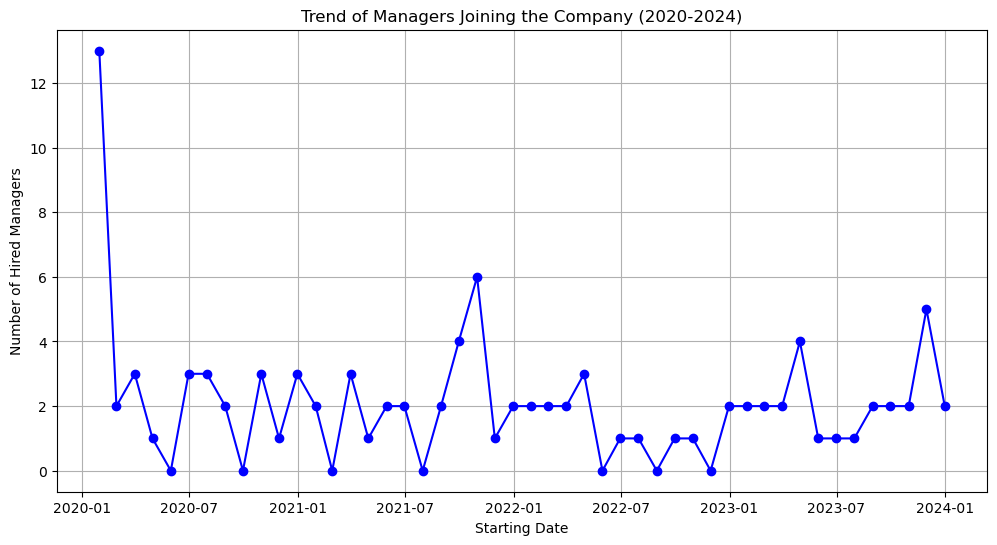

In [23]:
#B. switch to right date format for pandas:
managers_df_copy['starting_date'] = pd.to_datetime(managers_df_copy['starting_date'])
#make date a index
managers_date_df = managers_df_copy.set_index('starting_date')
monthly_joined = managers_date_df.resample(rule='ME')['manager_id'].count()
monthly_df = monthly_joined.reset_index(name='managers_count')

plt.figure(figsize=(12, 6))
plt.plot(monthly_df['starting_date'], monthly_df['managers_count'], marker='o', color='blue')
plt.title('Trend of Managers Joining the Company (2020-2024)')
plt.xlabel('Starting Date')
plt.ylabel('Number of Hired Managers')
plt.grid()
plt.show()

In [24]:
#C.
mean_salary_by_location = managers_df_copy.groupby('nationality')['salary'].mean().reset_index(name='mean_salary')
mean_salary_by_location

,nationality,mean_salary
0,Australia,31983.625000
1,Brazil,32366.333333
2,Canada,26575.000000
3,China,31134.000000
4,France,32902.000000
5,Germany,36665.560000
6,India,38523.200000
7,Israel,40927.666667
8,Italy,34363.125000
9,Japan,32121.916667


Mean amount of employees managed by managers hired from 2022 onwards: 3.9


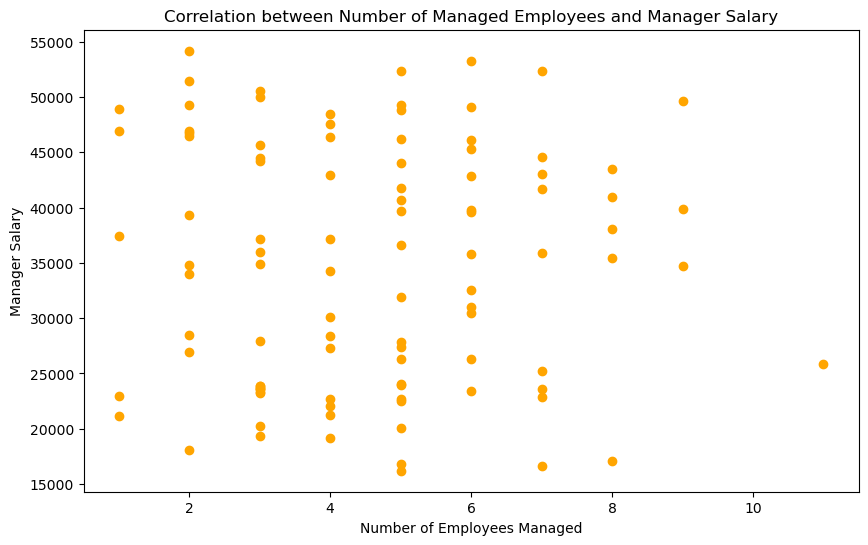

In [25]:
#D.
employee_counts_per_manager = employees_df_copy.groupby('manager_id').size().reset_index(name='employee_count')

managers_with_counts = managers_df_copy.merge(employee_counts_per_manager, on='manager_id', how='inner')

managers_with_counts['starting_date'] = pd.to_datetime(managers_with_counts['starting_date'])

managers_from_2022 = managers_with_counts[managers_with_counts['starting_date'] >= '2022-01-01']

mean_employees_managed = managers_from_2022['employee_count'].mean()
print("Mean amount of employees managed by managers hired from 2022 onwards:", mean_employees_managed)

plt.figure(figsize=(10, 6))
plt.scatter(managers_with_counts['employee_count'], managers_with_counts['salary'], color='orange')
plt.title('Correlation between Number of Managed Employees and Manager Salary')
plt.xlabel('Number of Employees Managed')
plt.ylabel('Manager Salary')
plt.show()

In [26]:
# there is no corallation between the number and the number of employees

           department  jobs_count
0              Design           5
1  Product Management           5
2     IT & Networking           5
3    Data & Analytics           5
4           Marketing           5
5                 R&D           4


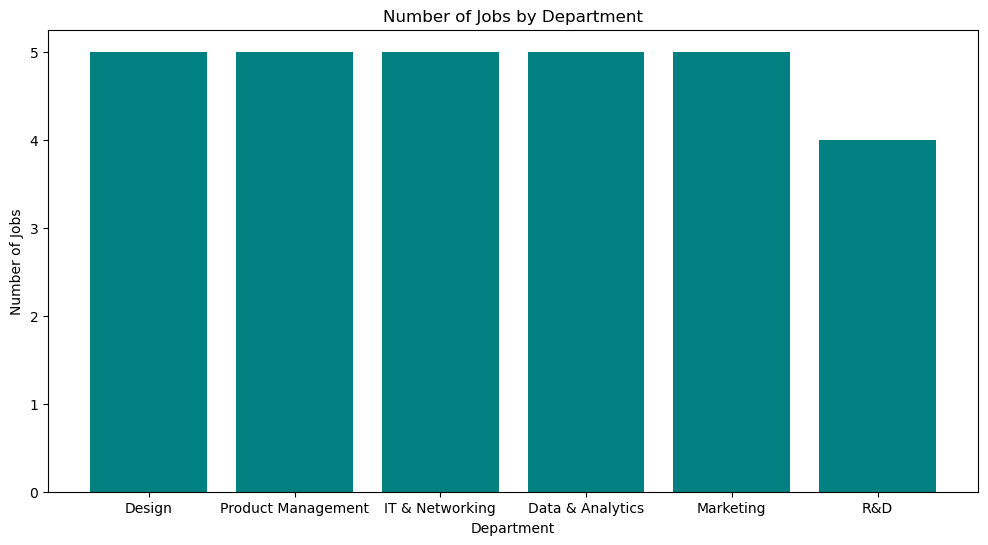

In [27]:
#3
department_counts = jobs_df_copy['department'].value_counts()
department_df = department_counts.reset_index(name='jobs_count')

department_df.columns = ['department', 'jobs_count']

print(department_df)

plt.figure(figsize=(12, 6))
plt.bar(department_df['department'], department_df['jobs_count'], color='teal')
plt.title('Number of Jobs by Department')
plt.xlabel('Department')
plt.ylabel('Number of Jobs')
plt.show()


   position_amount  employee_count
0              2.0             144
1              1.0             121
2              3.0              93
3              0.0              73
4              4.0              33
5              5.0              13
6              6.0               4
7              8.0               2


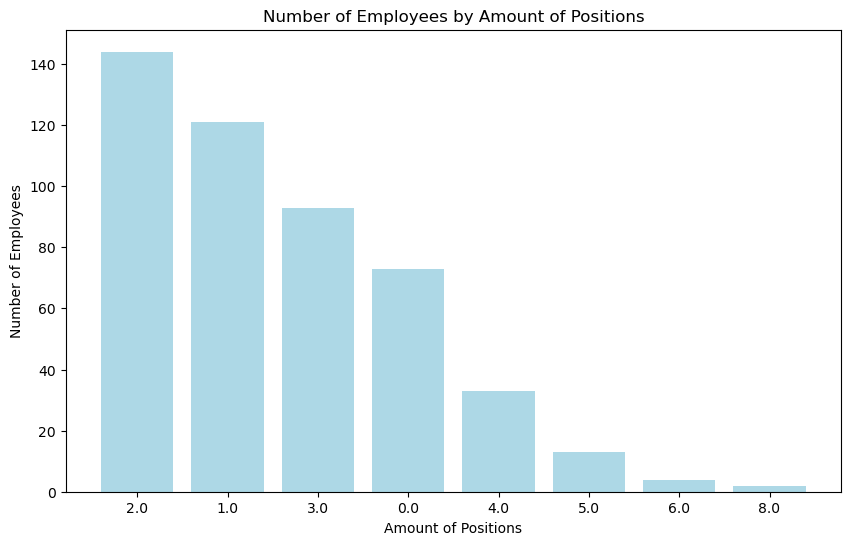

In [28]:
#4.
employees_df_copy.columns = employees_df_copy.columns.str.strip()
managers_df_copy.columns = managers_df_copy.columns.str.strip()
jobs_df_copy.columns = jobs_df_copy.columns.str.strip()
positions_df_copy.columns = positions_df_copy.columns.str.strip()
#a
pos_counts = positions_df_copy.groupby('employee_id').size().reset_index(name='position_count')
emp_positions_df = employees_df_copy.merge(pos_counts, on='employee_id', how='left')
emp_positions_df['position_count'] = emp_positions_df['position_count'].fillna(0)
pos_distribution = emp_positions_df['position_count'].value_counts().reset_index(name='employee_count')
pos_distribution.columns = ['position_amount', 'employee_count']


print(pos_distribution)

plt.figure(figsize=(10, 6))
plt.bar(pos_distribution['position_amount'].astype(str), pos_distribution['employee_count'], color='lightblue')
plt.title('Number of Employees by Amount of Positions')
plt.xlabel('Amount of Positions')
plt.ylabel('Number of Employees')
plt.show()

In [29]:
#B.
merged_nationality_df = employees_df_copy.merge(positions_df_copy, on='employee_id', how='inner')

different_loc_df = merged_nationality_df[merged_nationality_df['nationality'] != merged_nationality_df['position_location']]

mismatch_count = different_loc_df['employee_id'].nunique()
print("Number of employees working in positions different from their nationality:", mismatch_count)

Number of employees working in positions different from their nationality: 401


In [30]:
#C.
mean_perf_per_emp = positions_df_copy.groupby('employee_id')['performance_score'].mean().reset_index(name='mean_performance_score')


employees_df_copy = employees_df_copy.merge(mean_perf_per_emp, on='employee_id', how='left')


employees_df_copy['mean_performance_score'] = employees_df_copy['mean_performance_score'].fillna(0)

employees_df_copy.head()

,employee_id,manager_id,first_name,last_name,email,age,gender,nationality,years_of_experience,salary,mean_performance_score
0,1,0.0,Durant,Phripp,dphripp0@cbc.ca,60.0,Male,Italy,8.0,12184.0,6.000000
1,2,80.0,Chastity,MacHostie,cmachostie1@nytimes.com,63.0,Female,Germany,13.0,21968.0,7.500000
2,3,3.0,Rayna,Stemson,rstemson2@opensource.org,27.0,Unknown,Japan,12.0,28725.0,7.000000
3,4,94.0,Forest,Dillway,fdillway3@myspace.com,45.0,Male,Japan,8.0,29375.0,8.000000
4,5,25.0,Kristel,Mooreed,kmooreed4@thetimes.co.uk,24.0,Female,France,10.0,21709.0,7.666667


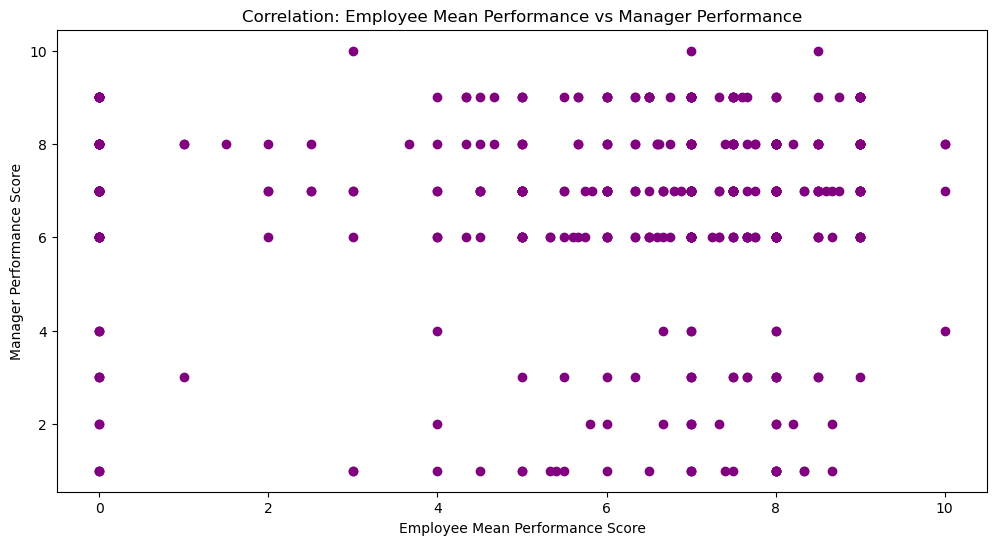

In [31]:
#D.
emp_mgr_perf_df = employees_df_copy.merge(managers_df_copy, on='manager_id', how='inner')
plt.figure(figsize=(12, 6))
plt.scatter(emp_mgr_perf_df['mean_performance_score'], emp_mgr_perf_df['performance_score'], color='purple')
plt.title('Correlation: Employee Mean Performance vs Manager Performance')
plt.xlabel('Employee Mean Performance Score')
plt.ylabel('Manager Performance Score')
plt.show()

In [32]:
# there is a sutlbe coralation between managers and employees score performance, most of the high performencees managers work with high performences employees

In [33]:
#E.
emp_pos_merge = employees_df_copy.merge(positions_df_copy, on='employee_id', how='inner')
full_job_merge = emp_pos_merge.merge(jobs_df_copy, on='job_id', how='inner')

dept_salary = full_job_merge.groupby('department')['salary'].sum().reset_index(name='total_salary_amount')
dept_emp_count = full_job_merge.groupby('department')['employee_id'].nunique().reset_index(name='amount_of_employees')

dept_summary = dept_salary.merge(dept_emp_count, on='department', how='inner')

dept_summary['mean_salary'] = dept_summary['total_salary_amount'] / dept_summary['amount_of_employees']
top_3_depts = dept_summary.sort_values(by='mean_salary', ascending=False).head(3)

final_top_3 = top_3_depts[['department', 'amount_of_employees', 'total_salary_amount']]
print(final_top_3)

           department  amount_of_employees  total_salary_amount
1              Design                  180            5221301.0
3           Marketing                  117            3174539.0
4  Product Management                   98            2620702.0


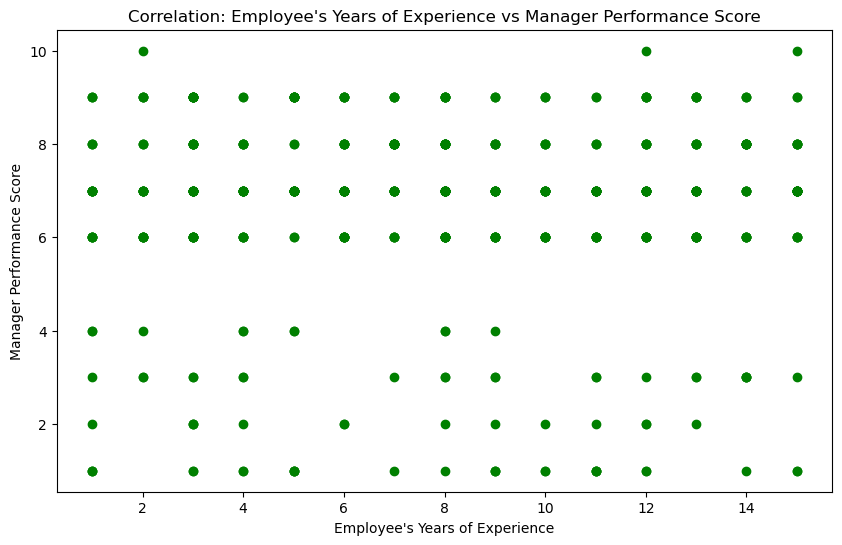

In [34]:
#F.
plt.figure(figsize=(10, 6))
plt.scatter(emp_mgr_perf_df['years_of_experience_x'], emp_mgr_perf_df['performance_score'], color='green')
plt.title("Correlation: Employee's Years of Experience vs Manager Performance Score")
plt.xlabel("Employee's Years of Experience")
plt.ylabel("Manager Performance Score")
plt.show()

In [35]:
#there is no corallation between managers high performances to employees years of experience.